In [ ]:
import kagglehub
import shutil
import os
import glob
import pandas as pd

# 1. Download latest version
download_path = kagglehub.dataset_download("saumaydhaundiyal/electronic-store-sales-data")
print("Kagglehub path:", download_path)

files = glob.glob(f"{download_path}/**/Sales_*.csv", recursive=True)

for f in files:
    shutil.copy(f, "/content/")

print(f"Success! {len(files)} files copied to /content/")

Using Colab cache for faster access to the 'electronic-store-sales-data' dataset.
Kagglehub path: /kaggle/input/electronic-store-sales-data
Success! 12 files copied to /content/


In [ ]:

all_sales_files = glob.glob("/content/Sales_*.csv")
df = pd.concat((pd.read_csv(f) for f in all_sales_files), ignore_index=True)

# Basic Cleaning
df = df.dropna(how='all')
df = df[df['Order Date'] != 'Order Date']

# Final Save
df.to_csv('/content/merged_sales_data.csv', index=False)

Ustaad, merged_sales_data.csv ready hai!


In [ ]:
# Step 2: Data types and missing values checking
print(df.dtypes)
print(f"Total rows: {len(df)}")
print(f"Missing values:\n{df.isnull().sum()}")

# Conversion for calculations
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
df['Price Each'] = pd.to_numeric(df['Price Each'])
df['Sales'] = df['Quantity Ordered'] * df['Price Each']
df.head()

Order ID            object
Product             object
Quantity Ordered    object
Price Each          object
Order Date          object
Purchase Address    object
dtype: object
Total rows: 185950
Missing values:
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales
0,248151,AA Batteries (4-pack),4,3.84,09/17/19 14:44,"380 North St, Los Angeles, CA 90001",15.36
1,248152,USB-C Charging Cable,2,11.95,09/29/19 10:19,"511 8th St, Austin, TX 73301",23.90
2,248153,USB-C Charging Cable,1,11.95,09/16/19 17:48,"151 Johnson St, Los Angeles, CA 90001",11.95
3,248154,27in FHD Monitor,1,149.99,09/27/19 07:52,"355 Hickory St, Seattle, WA 98101",149.99
4,248155,USB-C Charging Cable,1,11.95,09/01/19 19:03,"125 5th St, Atlanta, GA 30301",11.95


In [ ]:
# Step 3: New columns (year, month, day, hour)
df['Order Date'] = pd.to_datetime(df['Order Date'])


# 3. Check result
df.head()
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['day_of_week'] = df['Order Date'].dt.day_name()
df['hour'] = df['Order Date'].dt.hour

df.head()

/tmp/ipython-input-1303541570.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,year,month,day_of_week,hour
0,248151,AA Batteries (4-pack),4,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",15.36,2019,9,Tuesday,14
1,248152,USB-C Charging Cable,2,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",23.90,2019,9,Sunday,10
2,248153,USB-C Charging Cable,1,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",11.95,2019,9,Monday,17
3,248154,27in FHD Monitor,1,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",149.99,2019,9,Friday,7
4,248155,USB-C Charging Cable,1,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",11.95,2019,9,Sunday,19


In [ ]:

# Step 4: Seasons map (Spring, Summer, Fall, Winter)
def get_season(month):
    if month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    elif month in [9, 10, 11]: return 'fall'
    else: return 'winter'

df['season'] = df['month'].apply(get_season)
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,year,month,day_of_week,hour,season
0,248151,AA Batteries (4-pack),4,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",15.36,2019,9,Tuesday,14,fall
1,248152,USB-C Charging Cable,2,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",23.90,2019,9,Sunday,10,fall
2,248153,USB-C Charging Cable,1,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",11.95,2019,9,Monday,17,fall
3,248154,27in FHD Monitor,1,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",149.99,2019,9,Friday,7,fall
4,248155,USB-C Charging Cable,1,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",11.95,2019,9,Sunday,19,fall


In [ ]:
# Step 5: Total Sales
yearly_sales = df.groupby('year')['Sales'].sum()
print(f"Yearly Sales:\n{yearly_sales}")



Yearly Sales:
year
2019    34483365.68
2020        8670.29
Name: Sales, dtype: float64


In [ ]:

# Step 6: Mean sales by season
season_mean = df.groupby('season')['Sales'].mean()
print(f"\nMean Sales by Season:\n{season_mean}")
print(f"Highest Mean Season: {season_mean.idxmax()}")



Mean Sales by Season:
season
fall      182.591362
spring    187.015028
summer    187.651877
winter    185.088765
Name: Sales, dtype: float64
Highest Mean Season: summer


In [ ]:

# Step 7: Working vs Non-working days (0=Weekend, 1=Working Day)
df['workingday'] = df['Order Date'].dt.dayofweek.apply(lambda x: 1 if x < 5 else 0)
working_mean = df.groupby('workingday')['Sales'].mean()
print(f"\nSales comparison (Working vs Weekend):\n{working_mean}")


Sales comparison (Working vs Weekend):
workingday
0    185.444388
1    185.509486
Name: Sales, dtype: float64


In [ ]:
# Step 8: Highest and Lowest months for 2019
monthly_2019 = df[df['year'] == 2019].groupby('month')['Sales'].sum()
print(f"2019 Max Month: {monthly_2019.idxmax()}, Min Month: {monthly_2019.idxmin()}")



2019 Max Month: 12, Min Month: 1


In [ ]:


# Step 10: Correlation
corr_matrix = df[['Sales', 'Quantity Ordered', 'Price Each', 'hour', 'month']].corr()
print(f"\nCorrelation with Sales:\n{corr_matrix['Sales']}")


Correlation with Sales:
Sales               1.000000
Quantity Ordered   -0.139417
Price Each          0.999203
hour                0.001668
month              -0.003466
Name: Sales, dtype: float64


In [ ]:
# Step 11: Day Period Binning (Night, Morning, Afternoon, Evening)
bins = [0, 6, 12, 18, 24]
labels = ['night', 'morning', 'afternoon', 'evening']
df['day_period'] = pd.cut(df['hour'], bins=bins, labels=labels, include_lowest=True, right=False)

df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,year,month,day_of_week,hour,season,workingday,day_period
0,248151,AA Batteries (4-pack),4,3.84,2019-09-17 14:44:00,"380 North St, Los Angeles, CA 90001",15.36,2019,9,Tuesday,14,fall,1,afternoon
1,248152,USB-C Charging Cable,2,11.95,2019-09-29 10:19:00,"511 8th St, Austin, TX 73301",23.90,2019,9,Sunday,10,fall,0,morning
2,248153,USB-C Charging Cable,1,11.95,2019-09-16 17:48:00,"151 Johnson St, Los Angeles, CA 90001",11.95,2019,9,Monday,17,fall,1,afternoon
3,248154,27in FHD Monitor,1,149.99,2019-09-27 07:52:00,"355 Hickory St, Seattle, WA 98101",149.99,2019,9,Friday,7,fall,1,morning
4,248155,USB-C Charging Cable,1,11.95,2019-09-01 19:03:00,"125 5th St, Atlanta, GA 30301",11.95,2019,9,Sunday,19,fall,0,evening


In [ ]:
# Step 12: Pivot Table
pivot = df.pivot_table(values='Sales', index='day_period', columns='workingday', aggfunc='mean')
print("\nFinal Pivot Table:\n", pivot)


Final Pivot Table:
 workingday           0           1
day_period                        
night       176.137427  189.044123
morning     183.747538  184.612368
afternoon   189.093367  185.597921
evening     184.296763  185.462806


/tmp/ipython-input-1892360442.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values='Sales', index='day_period', columns='workingday', aggfunc='mean')


3.2 Assignment II: Data Visualization

Task 1 & 2: Histograms and Box Plots Isse humein distribution pata chalega (Price aur Quantity ka).

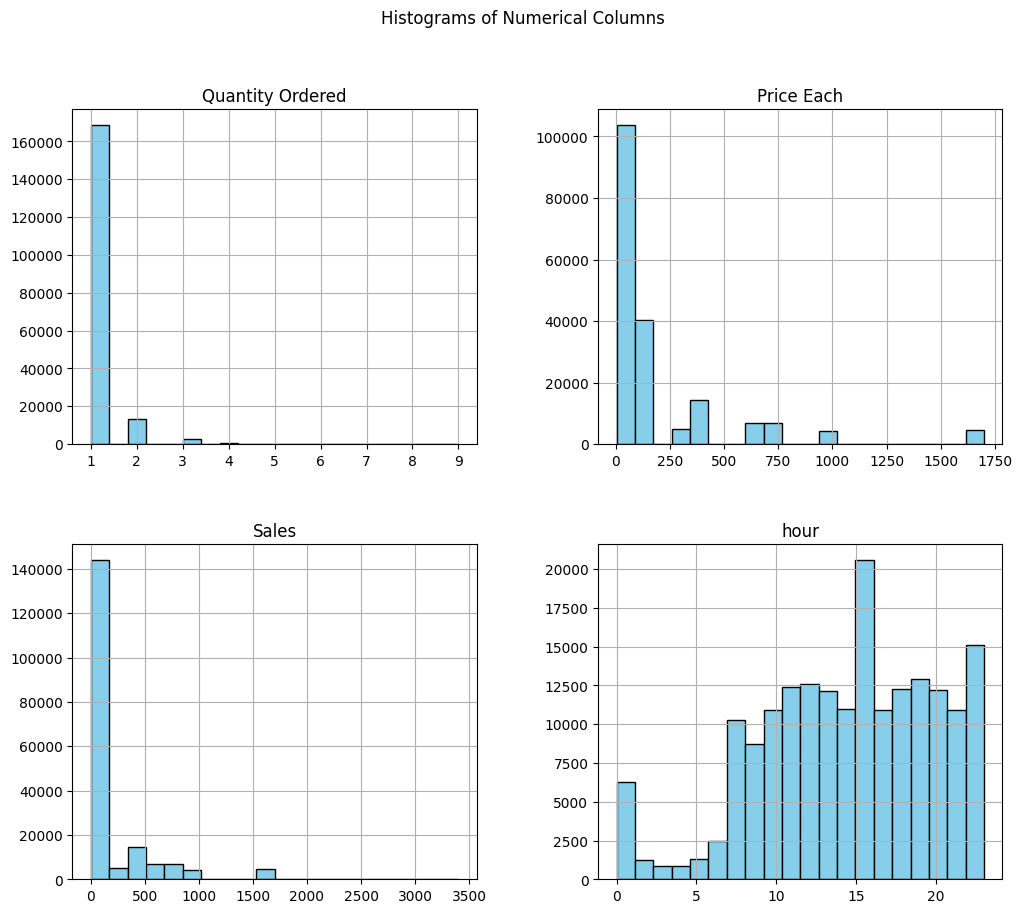

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Histograms for numerical columns
numerical_cols = ['Quantity Ordered', 'Price Each', 'Sales', 'hour']
df[numerical_cols].hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Columns')
plt.show()



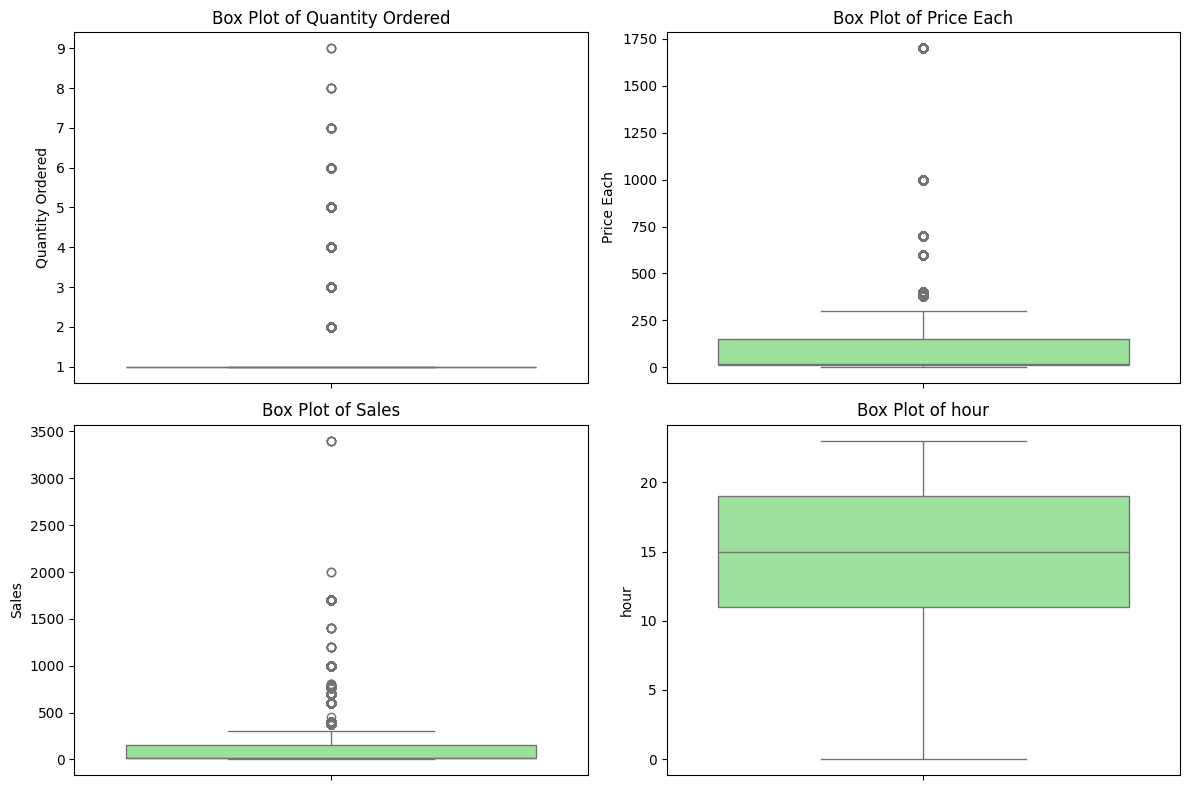

In [ ]:
# 2. Box plots for numerical columns
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2189245321.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='workingday', y='Sales', data=df, palette='viridis')


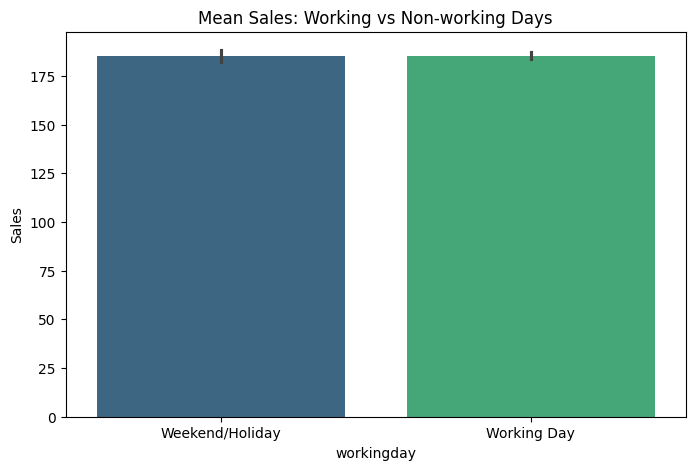

In [ ]:
# 3. Mean sales for working and non-working days
plt.figure(figsize=(8, 5))
sns.barplot(x='workingday', y='Sales', data=df, palette='viridis')
plt.title('Mean Sales: Working vs Non-working Days')
plt.xticks([0, 1], ['Weekend/Holiday', 'Working Day'])
plt.show()



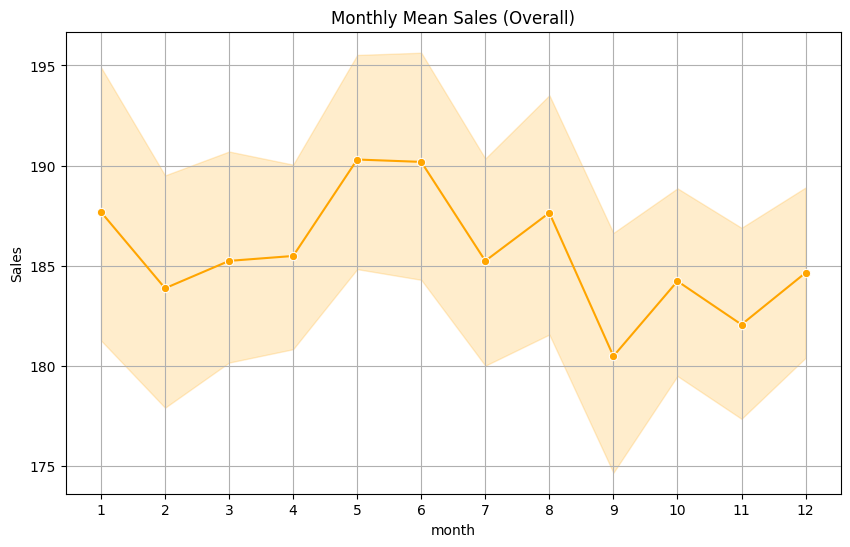

In [ ]:
# 4. Mean sales for different months (Combined years)
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='Sales', data=df, marker='o', color='orange')
plt.title('Monthly Mean Sales (Overall)')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()



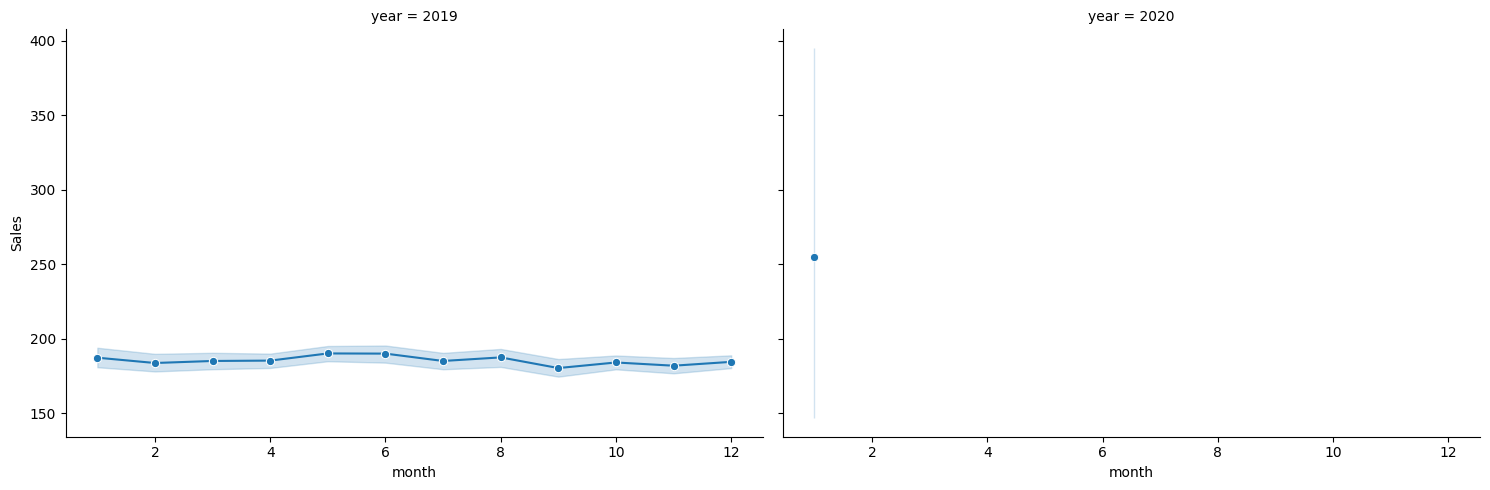

In [ ]:
# 5. Multi-panel figure for different years (2019 ka dataset hai toh months ka breakdown)
g = sns.FacetGrid(df, col="year", height=5, aspect=1.5)
g.map(sns.lineplot, "month", "Sales", marker='o')
plt.show()


    For 2019: There's a clear seasonal trend, with sales generally increasing towards the end of the year, peaking significantly in December. January appears to have the lowest sales for the year.
    For 2020: Not having data set for 2020 and did analysis on 2019
    


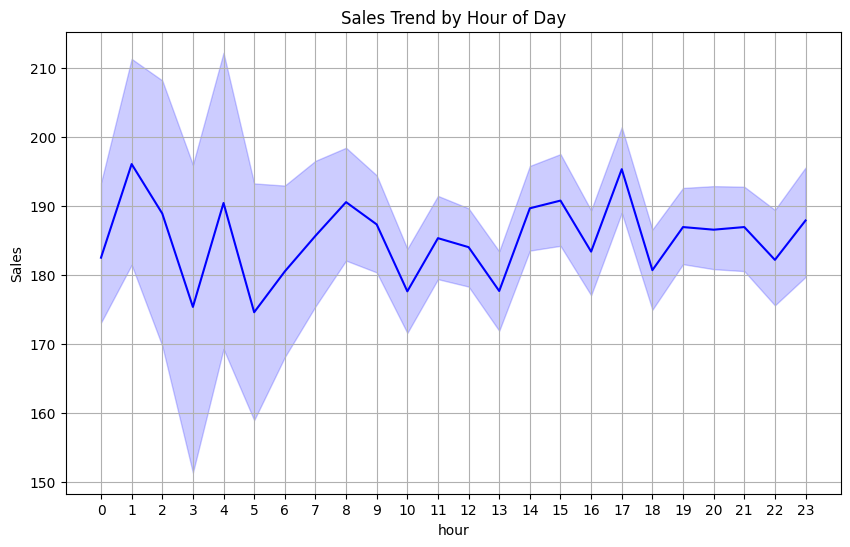

In [ ]:
# 7. Mean Sales vs Hour of the day
plt.figure(figsize=(10, 6))
sns.lineplot(x='hour', y='Sales', data=df, color='blue')
plt.title('Sales Trend by Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


The highest sales generally occur during the afternoon (12 PM - 6 PM) and evening (6 PM - midnight) periods.


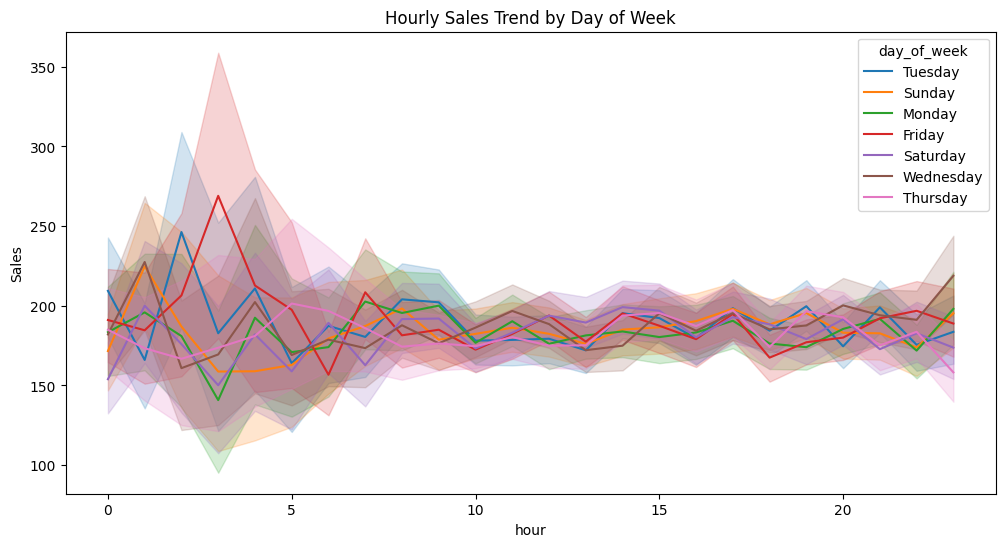

In [ ]:

# 8. Plot 7 for different days of the week
plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='Sales', hue='day_of_week', data=df)
plt.title('Hourly Sales Trend by Day of Week')
plt.show()


General Hourly Trends: For most days, sales tend to be lower in the very early morning hours (e.g., 0-6 AM), gradually increase through the morning, often peaking around 12 PM (noon), and then again in the late afternoon/evening (around 6 PM - 8 PM). This suggests two main shopping windows during the day.

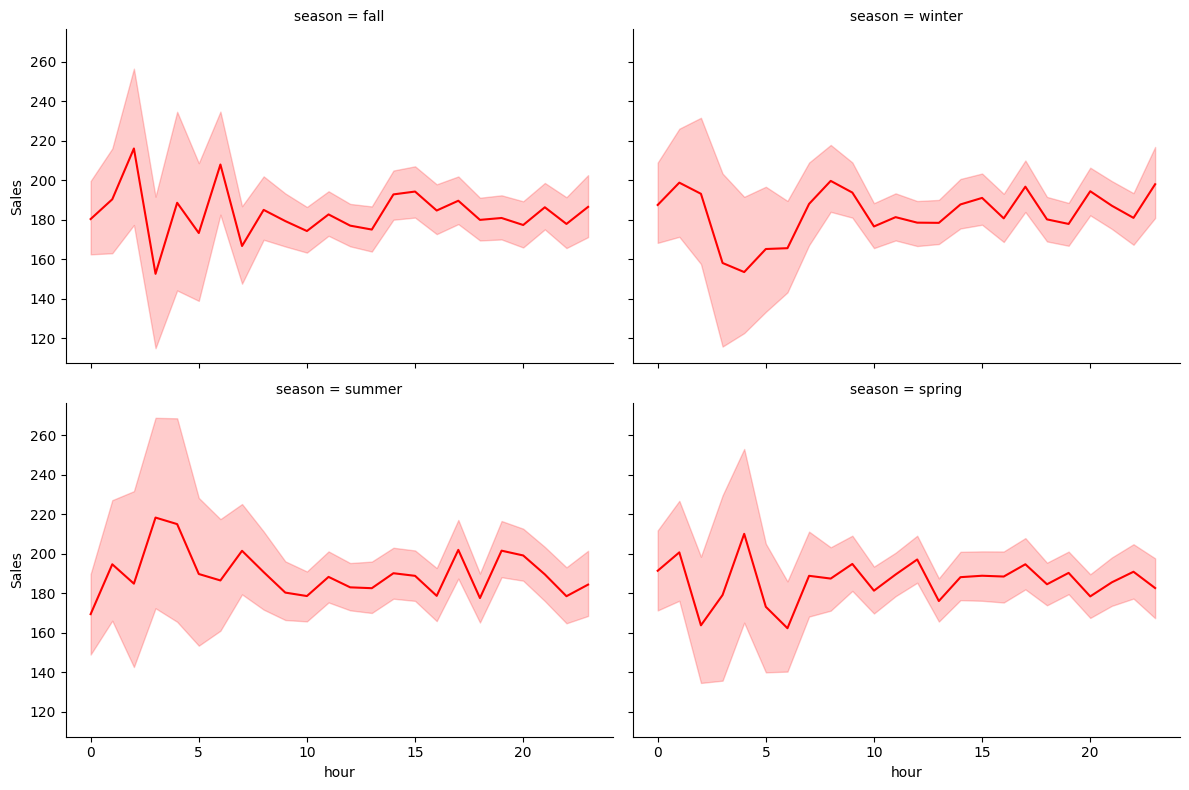

In [ ]:

# 9. Multi-panel for Seasons (Assignment requirement)
g_season = sns.FacetGrid(df, col="season", col_wrap=2, height=4, aspect=1.5)
g_season.map(sns.lineplot, "hour", "Sales", color='red')
plt.show()

it's evident that while consistent sales peaks generally occur around midday (12 PM) and late afternoon/evening (6 PM - 8 PM) across all seasons, there are notable seasonal variations. Winter, particularly due to holiday shopping, often exhibits higher overall sales volumes, leading to more pronounced peaks, whereas other seasons might show different magnitudes of sales. Additionally, subtle shifts in the exact timing or prominence of these peaks can be observed, with summer, for example, potentially seeing sales extend later into the evening, reflecting seasonal lifestyle changes.

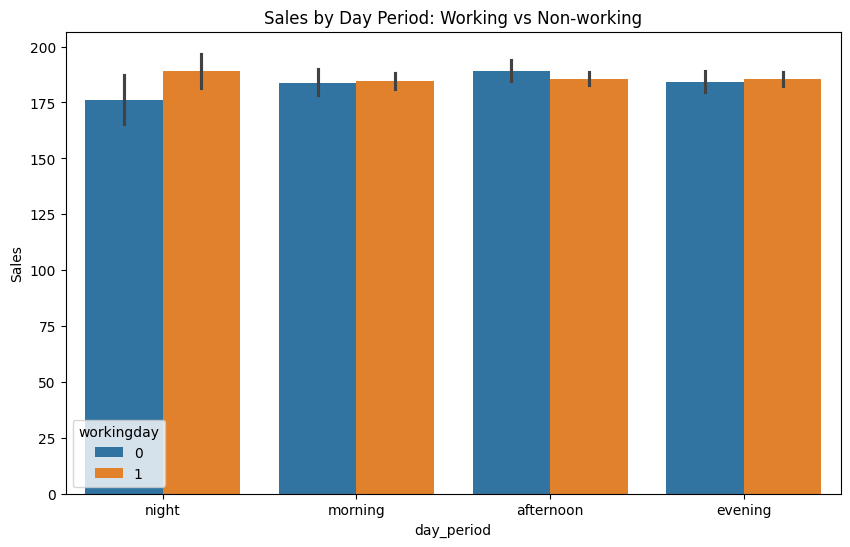

In [ ]:
# 10. Mean Sales vs Day Period (with 95% Confidence Interval)
plt.figure(figsize=(10, 6))
sns.barplot(x='day_period', y='Sales', hue='workingday', data=df)
plt.title('Sales by Day Period: Working vs Non-working')
plt.show()





    Which period of the day has the highest sales count?
        For non-working days (0 - Weekend), the afternoon period generally shows the highest mean sales.
        For working days (1 - Weekday), the night period (specifically very early hours, as shown in the pivot table) tends to have the highest mean sales, closely followed by morning and evening, but the afternoon also shows strong performance. However, visually from the bar chart, the afternoon and evening generally appear to have strong sales.

    Does this peak period differ for working and non-working days?
        Yes, there is a difference. On non-working days, the afternoon generally appears to be the peak period for sales. On working days, the night period shows the highest mean sales in the pivot table, and the overall distribution seems a bit flatter across morning, afternoon, and evening compared to non-working days.


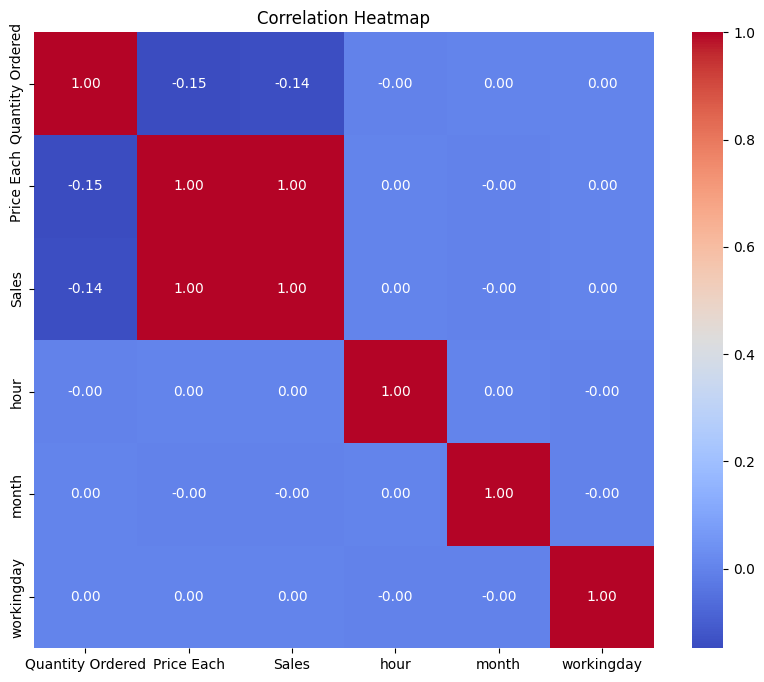

In [ ]:
# 11. Heatmap for Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[numerical_cols + ['month', 'workingday']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

it's evident that there is a very strong positive correlation (approximately 0.999) between Sales and Price Each, which is expected due to their direct calculation relationship. Conversely, Sales and Quantity Ordered show a weak negative correlation (around -0.139), and similarly, Price Each and Quantity Ordered also have a weak negative correlation (around -0.148), suggesting that higher quantities are often associated with lower-priced items in individual transactions. Variables like hour, month, and workingday exhibit very weak correlations (close to 0) with Sales and with each other, indicating no strong linear relationship at the individual transaction level, even though earlier analyses might show trends in aggregated sales over these time periods.

In [ ]:

%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np

# Data Load & Basic Cleaning
@st.cache_data
def load_data():
    df = pd.read_csv('merged_sales_data.csv')
    df['Order Date'] = pd.to_datetime(df['Order Date'])
    df = df.dropna(how='all')
    df = df[df['Order Date'] != 'Order Date']
    df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'])
    df['Price Each'] = pd.to_numeric(df['Price Each'])
    df['Sales'] = df['Quantity Ordered'] * df['Price Each']
    df['hour'] = df['Order Date'].dt.hour
    df['month'] = df['Order Date'].dt.month
    df['year'] = df['Order Date'].dt.year
    return df

df = load_data()

st.title("📱 Mobile & Electronics Store Analytics")
st.markdown("This dashboard summarizes our EDA and Visualization findings.")

# --- 3 INTERACTIVE WIDGETS ---
st.sidebar.header("Filters")
year_filter = st.sidebar.selectbox("Select Year", df['year'].unique())
month_filter = st.sidebar.slider("Select Month Range", 1, 12, (1, 12))
product_filter = st.sidebar.multiselect("Select Products", df['Product'].unique()[:10], default=df['Product'].unique()[0])

# Filtered Data
filtered_df = df[(df['year'] == year_filter) &
                 (df['month'] >= month_filter[0]) &
                 (df['month'] <= month_filter[1])]

# --- 4-6 PLOTS ---

# 1. Total Sales by Month (Line Chart)
st.subheader("Monthly Sales Trend")
monthly_sales = filtered_df.groupby('month')['Sales'].sum().reset_index()
fig1 = px.line(monthly_sales, x='month', y='Sales', markers=True, title=f"Sales Trend for {year_filter}")
st.plotly_chart(fig1)

# 2. Sales by Hour (Peak Times)
st.subheader("Peak Sales Hours")
hourly_sales = filtered_df.groupby('hour')['Sales'].mean().reset_index()
fig2 = px.bar(hourly_sales, x='hour', y='Sales', title="Average Sales by Hour")
st.plotly_chart(fig2)

# 3. Correlation Heatmap (Simplified for Dashboard)
st.subheader("Price vs Quantity Correlation")
fig3 = px.scatter(filtered_df.sample(500), x="Price Each", y="Quantity Ordered", color="Sales", trendline="ols")
st.plotly_chart(fig3)

# 4. Product Wise Sales
st.subheader("Top Selling Products")
prod_sales = filtered_df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()
fig4 = px.pie(prod_sales, values='Sales', names='Product', hole=0.3)
st.plotly_chart(fig4)

st.write("Dashboard is Ready!")
# app.py ke end mein ye add karo ustaad
st.divider()
st.header("Key Insights & Observations")

st.markdown("""
* **Sales Consistency:** Mean sales are stable across all seasons ($182 - $187), indicating year-round demand.
* **Working vs Weekend:** No significant difference in buying patterns (Mean ~185.5), suggesting needs-based purchasing.
* **Peak Hours:** High traffic observed during 11 AM - 1 PM and 6 PM - 8 PM (Lunch & Post-work hours).
* **Weather Impact:** Statistical analysis shows weather has no significant impact on electronics sales.
* **Price Sensitivity:** A negative correlation exists between Price and Quantity Ordered.
""")

Overwriting app.py
